# [TEMP] 7. Hardware and Tensor Parallelism

By [Kiwan Maeng](https://kiwanmaeng.com) ([LinkedIn](https://www.linkedin.com/in/kiwan-maeng-23b825165)) and [Claude Code](https://claude.com/claude-code) 🤖

Up to now everything ran on one A100. Real deployments have to choose:

- **Which GPU?** H100s are faster but cost more per hour.
- **How many GPUs per model replica?** A 70B model (140 GB in fp16) does not
  fit on one 80 GB GPU, so it *must* be split. Even a model that fits can be
  split to cut latency.

**Tensor parallelism (TP)** splits every weight matrix across $k$ GPUs. Each GPU
then reads $1/k$ of the weights per step, so memory-bound decode gets up to
$k\times$ faster, but the GPUs must **all-reduce** their partial results twice per
transformer layer. The simulator models both effects from profiled kernel and NCCL
runtimes.

:::{admonition} Learning goals
- Predict how TP changes latency, throughput, and per-GPU efficiency.
- Explain where the KV-cache memory goes and why TP also *adds* capacity.
- Choose a deployment for a given SLO and cost budget.
:::

## Setup

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

Simulator ready at /home/kiwan/.llm-systems-wo-gpus/backend


## What can we simulate?

The simulator can only simulate (model, GPU, TP) combinations that someone profiled on
real hardware. `lsg.catalog()` lists them:

In [2]:
lsg.catalog()

,device,model,tensor_parallel,max_context,max_batch
0,a100,Qwen/Qwen-72B,"[1, 2, 4, 8]",4096,128
1,a100,Qwen/Qwen2.5-32B-Instruct,"[2, 4, 8]",131104,128
2,a100,codellama/CodeLlama-34b-Instruct-hf,"[1, 2, 4, 8]",4096,128
3,a100,deepseek-ai/DeepSeek-R1-Distill-Llama-70B,"[4, 8]",131104,128
4,a100,deepseek-ai/DeepSeek-R1-Distill-Llama-8B,"[1, 2, 4]",131104,128
5,a100,internlm/internlm-20b,"[1, 2, 4, 8]",4096,128
6,a100,meta-llama/Llama-2-70b-hf,"[1, 2, 4, 8]",4096,128
7,a100,meta-llama/Llama-2-7b-hf,"[1, 2, 4, 8]",4096,128
8,a100,meta-llama/Meta-Llama-3-70B,"[4, 8]",262176,512
9,a100,meta-llama/Meta-Llama-3-8B,"[1, 8]",262176,512


## Sweeping GPU type and TP degree

For each configuration we measure:

- **Latency** at low load (one request at a time): TTFT and TPOT.
- **Capacity**: offline throughput with 256 requests queued at once, total and
  per GPU. Per-GPU throughput is a proxy for cost efficiency.
- **KV-cache capacity**: how many tokens of context fit in memory after the weights.

In [3]:
def characterize(model, device, tp):
    lo = lsg.simulate(model=model, device=device, tensor_parallel=tp, qps=0.1, num_requests=10)
    hi = lsg.simulate(model=model, device=device, tensor_parallel=tp, qps=None, num_requests=256)
    s_lo, s_hi = lo.summary(), hi.summary()
    return {"model": model.split("/")[-1], "GPU": device, "TP": tp,
            "TTFT (ms)": s_lo["TTFT p50 (ms)"], "TPOT (ms)": s_lo["TPOT p50 (ms)"],
            "tok/s": s_hi["throughput (tok/s)"],
            "tok/s per GPU": s_hi["throughput (tok/s)"] / tp,
            "KV tokens": lo.kv_cache_tokens}

rows = []
for device in ("a100", "h100"):
    for tp in (1, 2, 4, 8):
        rows.append(characterize("meta-llama/Llama-2-7b-hf", device, tp))
    for tp in (2, 4, 8):
        rows.append(characterize("meta-llama/Llama-2-70b-hf", device, tp))
hw = pd.DataFrame(rows).round(1)
hw

,model,GPU,TP,TTFT (ms),TPOT (ms),tok/s,tok/s per GPU,KV tokens
0,Llama-2-7b-hf,a100,1,36.6,9.4,9034.4,9034.4,122752
1,Llama-2-7b-hf,a100,2,23.8,8.6,13959.6,6979.8,270208
2,Llama-2-7b-hf,a100,4,16.7,5.7,21120.3,5280.1,565120
3,Llama-2-7b-hf,a100,8,13.1,4.8,28577.7,3572.2,1154944
4,Llama-2-70b-hf,a100,2,193.4,54.9,2234.1,1117.1,54064
5,Llama-2-70b-hf,a100,4,114.4,35.7,3987.1,996.8,525920
6,Llama-2-70b-hf,a100,8,79.4,20.9,5783.5,722.9,1469632
7,Llama-2-7b-hf,h100,1,13.8,5.8,19165.0,19165.0,122752
8,Llama-2-7b-hf,h100,2,10.2,4.0,28700.9,14350.4,270208
9,Llama-2-7b-hf,h100,4,8.3,4.5,38734.5,9683.6,565120


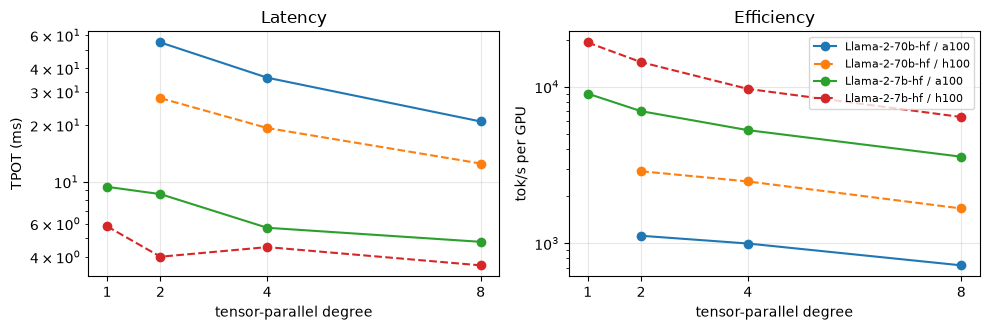

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
for (model, device), g in hw.groupby(["model", "GPU"]):
    style = "-" if device == "a100" else "--"
    ax[0].plot(g["TP"], g["TPOT (ms)"], "o" + style, label=f"{model} / {device}")
    ax[1].plot(g["TP"], g["tok/s per GPU"], "o" + style, label=f"{model} / {device}")
ax[0].set(xlabel="tensor-parallel degree", ylabel="TPOT (ms)", title="Latency", yscale="log")
ax[1].set(xlabel="tensor-parallel degree", ylabel="tok/s per GPU", title="Efficiency", yscale="log")
for a in ax:
    a.set_xticks([1, 2, 4, 8])
ax[1].legend(fontsize=8)
fig.tight_layout()

Things to notice:

1. **TP lowers latency, sub-linearly.** Going from TP2 to TP8 on Llama-2-70B cuts
   TPOT by about 2–2.6×, not 4×, because each all-reduce costs a roughly fixed time
   regardless of how small the shards get.
2. **TP lowers per-GPU efficiency.** Each GPU does less useful math per step, and
   communication time does not shrink. If you only care about throughput per
   dollar and the model fits, use the *smallest* TP and add replicas instead
   (lecture 8).
3. **H100 vs. A100** is roughly 2× on both latency and throughput, broadly in
   line with its higher memory bandwidth (3.35 vs. 2.0 TB/s) and FLOPs.
4. **KV-cache capacity grows super-linearly with TP.** 70B at TP2 has 160 GB of
   HBM and 140 GB of weights, which leaves room for only ~54k tokens of KV
   cache, i.e. a few dozen concurrent long chats. At TP4 the same weights are
   spread over 320 GB, so KV capacity grows ~10×. A larger KV cache allows
   larger batches. Our short 640-token requests never fill even TP2's cache,
   which is why TP2 looks so efficient here. Exercise 1 asks what happens
   with long contexts.

:::{note}
The per-token KV size is
$2 \times n_\text{layers} \times n_\text{kv heads} \times d_\text{head} \times 2\ \text{B}$.
Llama-2-70B uses grouped-query attention with 8 KV heads, so it needs
$2 \times 80 \times 8 \times 128 \times 2 = 320$ KB per token, *less* than
Llama-2-7B's 512 KB, despite having 10× the parameters.
:::

## Exercises

:::{admonition} Try it
:class: exercise
1. Rerun the 70B rows with long requests (`prefill_tokens=3000, decode_tokens=500`)
   and `batch_size_cap=128`. Does TP2 still win on tokens/s per GPU? Look at
   `kv_cache_tokens` to explain why or why not.
2. Price the configurations: assume $2/h for an A100 and $4/h for an H100. Which
   deployment of Llama-2-70B gives the lowest **cost per million output tokens**
   while keeping TPOT under 30 ms?
3. Compare one replica at TP8 against two replicas at TP4 (`num_replicas=2`) for
   Llama-2-70B at 8 req/s. Which has better p99 TTFT? Which has better TPOT?
:::